In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [11]:
spect_1 = pd.read_csv("spectrum_075.csv", sep = ";")
spect_2 = pd.read_csv("spectrum_085.csv", sep = ";")
spect_5 = pd.read_csv("spectrum_095.csv", sep = ";")
spect_6 = pd.read_csv("spectrum_105.csv", sep = ";")

In [31]:
spect_2.Фаза

0      3.141593
1      1.394157
2      1.210374
3      0.989294
4      0.976937
         ...   
995   -1.056615
996   -0.976937
997   -0.989294
998   -1.210374
999   -1.394157
Name: Фаза, Length: 1000, dtype: float64

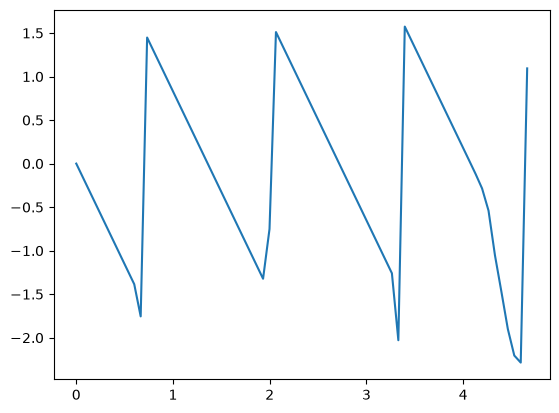

In [28]:
middle = int(len(spect_1.Частота) / 2)
plt.plot(spect_1.Частота[middle:middle + 71], spect_1.Фаза[middle:middle + 71])

In [27]:
spect_1.Частота[middle + 71]

np.float64(4.728599999999958)

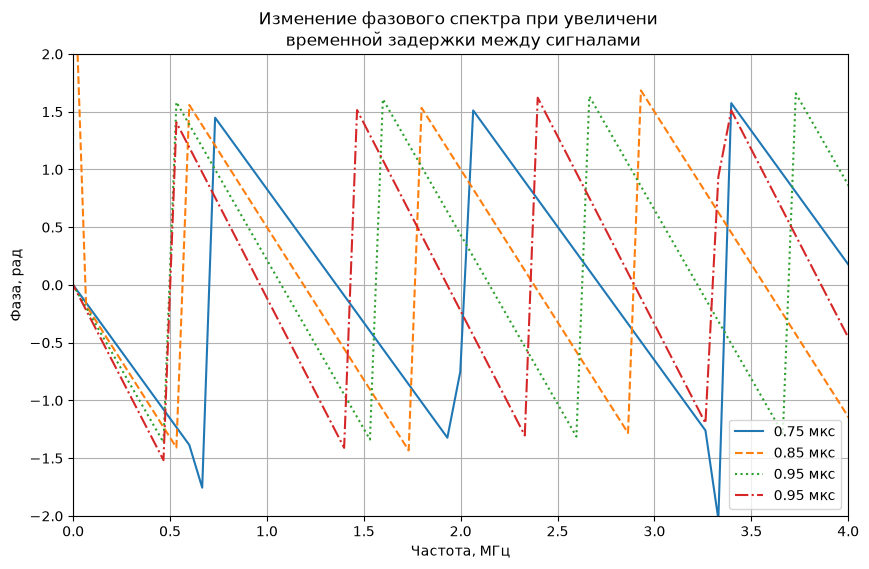

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(spect_1.Частота, spect_1.Фаза, label = "0.75 мкс", linestyle = '-')
plt.plot(spect_1.Частота, spect_2.Фаза, label = "0.85 мкс", linestyle = '--')
plt.plot(spect_1.Частота, spect_5.Фаза, label = "0.95 мкс", linestyle = 'dotted')
plt.plot(spect_1.Частота, spect_6.Фаза, label = "1.05 мкс", linestyle = 'dashdot')
plt.title("Изменение фазового спектра при увеличени \n временной задержки между сигналами")
plt.xlim(0,4)
plt.xlabel("Частота, МГц")
plt.ylim(-2,2)
plt.ylabel("Фаза, рад")
plt.legend()
plt.grid()

In [48]:
spect_3 = pd.read_csv("spectrum_new_09.csv", sep = ";")
spect_4 = pd.read_csv("spectrum_new_10.csv", sep = ";")

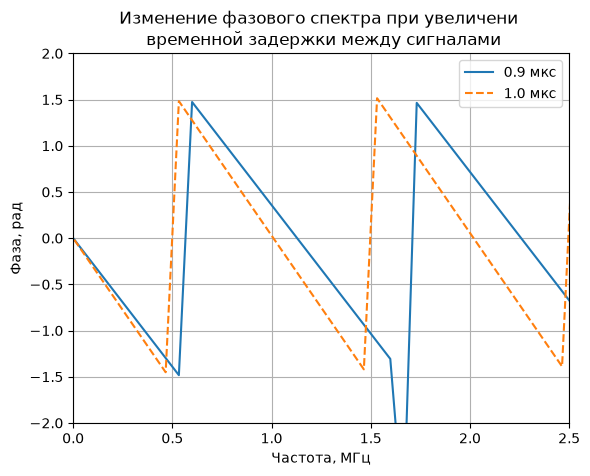

In [50]:
plt.plot(spect_3.Частота, spect_3.Фаза, label = "0.9 мкс", linestyle = '-')
plt.plot(spect_3.Частота, spect_4.Фаза, label = "1.0 мкс", linestyle = '--')
plt.title("Изменение фазового спектра при увеличени \n временной задержки между сигналами")
plt.xlim(0,2.5)
plt.xlabel("Частота, МГц")
plt.ylim(-2,2)
plt.ylabel("Фаза, рад")
plt.legend()
plt.grid()

C:\Users\ДЮПС\AppData\Local\Temp\ipykernel_7684\1041677101.py:10: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  plt.scatter(shifts, periods, marker = ',', c = 'black')
C:\Users\ДЮПС\AppData\Local\Temp\ipykernel_7684\1041677101.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


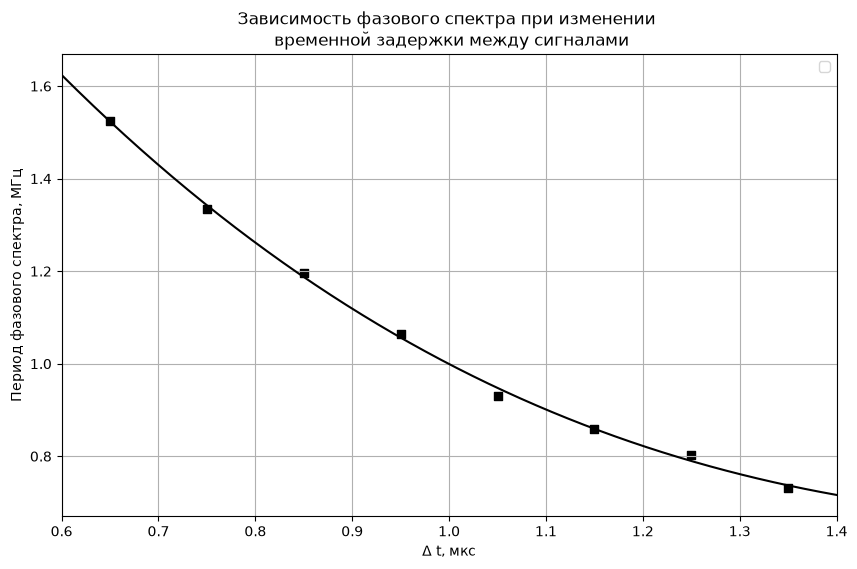

In [32]:
shifts = np.array([0.65, 0.75, 0.85, 0.95, 1.05, 1.15, 1.25, 1.35])
periods = np.array([1.525, 1.334, 1.197, 1.064, 0.931, 0.858, 0.802, 0.732])
xlims = (0.6, 1.4)
shifts_axis = np.linspace(xlims[0], xlims[1], 50, endpoint = True)
coeffs = np.polyfit(shifts, periods, deg=3)
p = np.poly1d(coeffs)
periods_predict = p(shifts_axis)

plt.figure(figsize = (10,6))
plt.scatter(shifts, periods, marker = ',', c = 'black')
plt.plot(shifts_axis, periods_predict, c = 'black')
plt.title("Зависимость фазового спектра при изменении \n временной задержки между сигналами")
plt.xlim(xlims[0], xlims[1])
plt.xlabel("Δ t, мкс")
plt.ylabel("Период фазового спектра, МГц")
plt.legend()
plt.grid()

In [ ]:
# Степень полинома = 2
coeffs = np.polyfit(shifts, periods, deg=2)
print("Коэффициенты полинома (от старшей степени к младшей):", coeffs)

# Предсказание значений
p = np.poly1d(coeffs)
y_pred = p(shifts)

Коэффициенты полинома (от старшей степени к младшей): [ 1.06845238 -3.25130952  3.18213839]


In [29]:
y_pred

array([1.52020833, 1.34466071, 1.19048214, 1.05767262, 0.94623214,
       0.85616071, 0.78745833, 0.740125  ])